# 14.4: Anchor Boxes

In [2]:
%matplotlib inline
import torch
from d2l import torch as d2l

torch.set_printoptions(2) # Simply printing accuracy

## 14.4.1: Generating Multiple Anchor Boxes

In [3]:
#@save
def multibox_prior(data, sizes, ratios):
    """Generate anchor boxes with different shapes centered on each pixel."""
    in_height, in_width = data.shape[-2:]
    device, num_sizes, num_ratios = data.device, len(sizes), len(ratios)
    boxes_per_pixel = (num_sizes + num_ratios - 1) # n + m - 1
    size_tensor = torch.tensor(sizes, device=device)
    ratio_tensor = torch.tensor(ratios, device=device)
    # Offsets are required to move the anchor to the center of a pixel. SInce
    # a pixel has height=1 and width=1, we choose to offset our centers by 0.5
    offset_h, offset_w = 0.5, 0.5
    steps_h = 1.0 / in_height # Scaled steps in y axis
    steps_w = 1.0 / in_width # Scaled steps in x axis

    # Generate all center points for the anchor boxes
    center_h = (torch.arange(in_height, device=device) + offset_h) * steps_h
    center_w = (torch.arange(in_width, device=device) + offset_w) * steps_w
    shift_y, shift_x = torch.meshgrid(center_h, center_w, indexing='ij')
    shift_y, shift_x = shift_y.reshape(-1), shift_x.reshape(-1)

    # Generate `boxes_per_pixel` number of heights and widths that are later 
    # used to create anchor box corner coordinates (xmin, xmax, ymin, ymax)
    w = torch.cat((size_tensor * torch.sqrt(ratio_tensor[0]),
                   sizes[0]  * torch.sqrt(ratio_tensor[1:]))) \
                    * in_height / in_width # Handle rectangular widths
    h = torch.cat((size_tensor / torch.sqrt(ratio_tensor[0]),
                   sizes[0] / torch.sqrt(ratio_tensor[1:])))
    # Divide by 2 to get half height and half width
    anchor_manipulations = torch.stack((-w,-h,w,h)).T.repeat(
        in_height * in_width, 1) / 2
    
    # Each center point will have `boxes_per_pixel` number of anchor boxes, so
    # generate a grid of all anchor box centers with `boxes_per_pixel` repeats
    out_grid = torch.stack([shift_x, shift_y, shift_x, shift_y],
                           dim=1).repeat_interleave(boxes_per_pixel, dim=0) # repeat input matrix `boxes_per_pixel` many times along the rows
    output = out_grid + anchor_manipulations
    return output.unsqueeze(0)

In [ ]:
img = d2l.plt.imread('../catdog.png')
h,w = img.shape[:2]

print(h,w)
X = torch.rand(size=(1,3,h,w)) # Construct input data
Y = multibox_prior(X, sizes=[0.75, 0.5, 0.25], ratios=[1,2,0.5])
Y.shape # (batch_size, number_of_anchor_boxes, 4)

203 268


torch.Size([1, 272020, 4])

In [5]:
boxes = Y.reshape(h,w,5,4)
boxes[150,150,0,:]

tensor([0.28, 0.37, 0.85, 1.12])

In [6]:
#@save
def show_bboxes(axes, bboxes, labels=None, colors=None):
    """Show bounding boxes"""

    def make_list(obj, default_values=None):
        if obj is None:
            obj = default_values
        elif not isinstance(obj, (list, tuple)):
            obj = [obj]
        return obj
    
    labels = make_list(labels)
    colors = make_list(colors, ['b', 'g', 'r', 'm', 'c'])
    for i, bbox in enumerate(bboxes):
        color = colors[i % len(colors)]
        rect = d2l.bbox_to_rect(bbox.detach().numpy(), color)
        axes.add_patch(rect)
        if labels and len(labels) > i:
            text_color = 'k' if color == 'w' else 'w'
            axes.text(rect.xy[0], rect.xy[1], labels[i],
                      va='center', ha='center', fontsize=9, color=text_color,
                      bbox=dict(facecolor=color, lw=0))

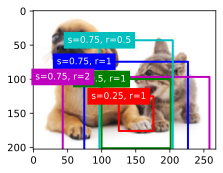

In [ ]:
d2l.set_figsize()
bbox_scale = torch.tensor((w,h,w,h))
fig = d2l.plt.imshow(img)
show_bboxes(fig.axes, boxes[150,150,:,:] * bbox_scale, 
            ['s=0.75, r=1', 's=0.5, r=1', 's=0.25, r=1', 's=0.75, r=2', 
             's=0.75, r=0.5']) # display bounding boxes centered on 150,150